# Variables & Outliers — EDA for the price model

This notebook documents the data that feeds the price-estimation model, in three parts:

1. **The schema of the raw variables** — every column loaded from the DB, its type, how many values are missing, its range.
2. **The outliers** — the two cleaning stages (`basic_filters` then the IQR/Tukey fence) that decide which listings are excluded from training, visualised.
3. **The derived features** — the columns the model *actually* trains on, including the ones built on the fly from text (`neighborhood`, `delegation`, the `land_*` flags) that are not stored in the DB.

It reuses the **exact same functions** as the training pipeline — `basic_filters`, `compute_outlier_bounds`, `apply_outlier_bounds` (from `prepare_training_data.py`) and `to_feature_frame` (from `features.py`) — so what you see here matches what the model actually trains on, with no separate copy of the logic that could drift.

### How to run
- Make sure the stack is up (`docker compose up -d`) so Postgres is reachable.
- Requirements on your host: `pip install pandas numpy matplotlib psycopg2-binary`
- Run the cells top to bottom.

> The DB connection targets `127.0.0.1:5434` — the address docker-compose publishes Postgres on for the host. (Inside the container it's `db:5432`; that hostname only resolves within the docker network, so it won't work from here.)

## 0. Setup & imports

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
import psycopg2

# Make the `scraper` package importable so we reuse the SAME cleaning code the
# model training uses (no drift between this notebook and production).
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "scraper").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from scraper.ml.prepare_training_data import (
    FEATURE_COLUMNS,
    basic_filters,
    compute_outlier_bounds,
    apply_outlier_bounds,
    MIN_SALE_PRICE,
    MIN_RENT_PRICE,
    MIN_OUTLIER_GROUP_SIZE,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
print("repo root:", REPO_ROOT)

repo root: c:\Users\ASUS\Desktop\rews


## 1. Connect to the database and load the raw listings

Same query as `load_raw_properties()`: one row per ad (the latest scrape of each `source + ad_id`).

In [2]:
# Read the DB password from .env, but force host/port to the host-published
# address (the .env values `db:5432` only resolve inside the docker network).
def read_env(path):
    env = {}
    p = Path(path)
    if p.exists():
        for line in p.read_text(encoding="utf-8").splitlines():
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                k, v = line.split("=", 1)
                env[k.strip()] = v.strip()
    return env

_env = read_env(REPO_ROOT / ".env")
DB = dict(
    host="127.0.0.1",
    port=5434,
    dbname=_env.get("DB_NAME", "realestate"),
    user=_env.get("DB_USER", "postgres"),
    password=_env.get("DB_PASSWORD", "postgres"),
)

query = f"""
    SELECT DISTINCT ON (source, ad_id) {", ".join(FEATURE_COLUMNS)}
    FROM properties
    ORDER BY source, ad_id, id DESC
"""
with psycopg2.connect(**DB) as conn:
    raw = pd.read_sql(query, conn)

print(f"{len(raw):,} unique listings loaded")
raw.head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20452\2548234227.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  raw = pd.read_sql(query, conn)


15,299 unique listings loaded


,id,source,property_type,listing_type,price,area,governorate,city,address,title,description,bedrooms,garage,furnished,terrace,pool,subcategory
0,51122,expat,house,rent,0.0,NaN,Tunis,Carthage,Carthage,"A LOUER UNE VILLA AVEC JARDIN, PISCINE ET UNE ...",A louer une villa située dans un quartier pres...,4.0,False,True,True,True,house
1,51108,expat,house,rent,0.0,NaN,Ariana,11 Rue Taoufik El Ebdelli,"11 Rue Taoufik El Ebdelli, Ariana 2080",Maison / Villa Tunisie 400 m2,"Villa / Maison avec Jardin et terrasses , 400m...",5.0,False,True,True,True,house
2,51121,expat,house,rent,0.0,NaN,Tunis,Carthage,Carthage,"A louer une villa avec jardin et piscine, en S...","A louer une villa avec jardin et piscine, en S...",3.0,False,True,True,True,house
3,51123,expat,house,rent,0.0,NaN,Tunis,Cité les Pins la marsa,Cité les Pins la marsa,Location maison meublée la marsa,Je loue une maison meublée avec 3 chambres 2sa...,3.0,False,True,True,False,house
4,51095,expat,house,rent,0.0,NaN,Jasmin,Jasmin,Jasmin,Villa de luxe à louer à Sidi El Mahrsi. Surfac...,Location annuelle Villa meublé S+3 avec suite ...,3.0,True,True,True,True,house


## 2. Variable schema (raw source columns)

The raw columns `load_raw_properties()` pulls from the DB — one row per ad — with data-quality signals: dtype, how many values are missing, how many distinct values, and the numeric range. This is where you spot problems (e.g. a price `max` in the trillions = garbage to be filtered later).

These are the *source* columns; not all of them are fed to the model directly:
- `id` / `source` are identifiers, not features.
- `address`, `title`, `description` are free text — the model never sees them raw; they're the input the derived `neighborhood`, `delegation` and `land_*` features are built from (see **Section 6**).

The `bedrooms` and `garage / furnished / terrace / pool` columns are sparse because the source sites often omit them; they have since been **back-filled from the listing text** where possible, so their coverage here is higher than a raw first scrape would show.

In [3]:
def schema_report(df):
    rows = []
    for col in df.columns:
        s = df[col]
        info = {
            "column": col,
            "dtype": str(s.dtype),
            "non_null": int(s.notna().sum()),
            "nulls": int(s.isna().sum()),
            "null_%": round(100 * s.isna().mean(), 1),
            "unique": int(s.nunique(dropna=True)),
        }
        if pd.api.types.is_numeric_dtype(s) and s.notna().any():
            info["min"] = round(float(s.min()), 2)
            info["median"] = round(float(s.median()), 2)
            info["max"] = round(float(s.max()), 2)
        rows.append(info)
    return pd.DataFrame(rows)

schema_report(raw)

,column,dtype,non_null,nulls,null_%,unique,min,median,max
0,id,int64,15299,0,0.0,15299,51094.0,58747.0,6.639600e+04
1,source,str,15299,0,0.0,3,NaN,NaN,NaN
2,property_type,str,15299,0,0.0,5,NaN,NaN,NaN
3,listing_type,str,15299,0,0.0,2,NaN,NaN,NaN
4,price,float64,15299,0,0.0,1797,-3.0,2200.0,1.111111e+14
5,area,float64,11522,3777,24.7,1669,1.0,250.0,6.900000e+05
6,governorate,str,15299,0,0.0,44,NaN,NaN,NaN
7,city,str,15299,0,0.0,234,NaN,NaN,NaN
8,address,str,15299,0,0.0,719,NaN,NaN,NaN
9,title,str,15299,0,0.0,13356,NaN,NaN,NaN


### Category breakdowns
The categorical features the model splits on. Watch for lopsided classes (few offices vs many apartments).

In [4]:
for col in ["source", "listing_type", "property_type", "governorate"]:
    print(f"\n===== {col} =====")
    print(raw[col].value_counts(dropna=False).head(12))


===== source =====
source
tayara     9248
mubawab    5977
expat        74
Name: count, dtype: int64

===== listing_type =====
listing_type
sale    8967
rent    6332
Name: count, dtype: int64

===== property_type =====
property_type
land         5855
apartment    5146
house        2179
office       1153
studio        966
Name: count, dtype: int64

===== governorate =====
governorate
Tunis        5997
Nabeul       2326
Ariana       1891
Sousse       1451
Ben Arous     917
Sfax          610
Bizerte       457
Mahdia        346
Manouba       317
Monastir      292
Médenine      267
Zaghouan       68
Name: count, dtype: int64


## 3. Stage 1 — basic filters

`basic_filters()` drops rows that can teach the model nothing: missing required fields, non-positive area, and **placeholder prices** (a sale under 1000 TND is "price on request", not a real price; rent under 1 TND). The exact thresholds live in `MIN_SALE_PRICE` / `MIN_RENT_PRICE`.

In [5]:
before = len(raw)
filtered = basic_filters(raw)
after = len(filtered)
print(f"Stage 1: {before:,} -> {after:,}   ({before - after:,} rows dropped)")

# Why rows get dropped (reasons overlap, so these are indicative counts, not a
# partition — a row can be both missing-area and a placeholder price).
r = raw
breakdown = pd.DataFrame({
    "reason": [
        "missing price / area / governorate",
        "area <= 0",
        f"sale price <= {MIN_SALE_PRICE} (placeholder)",
        f"rent price <= {MIN_RENT_PRICE} (placeholder)",
    ],
    "rows_matching": [
        int(r[["price", "area", "governorate"]].isna().any(axis=1).sum()),
        int((r["area"].fillna(0) <= 0).sum()),
        int(((r["listing_type"] == "sale") & (r["price"].fillna(0) <= MIN_SALE_PRICE)).sum()),
        int(((r["listing_type"] != "sale") & (r["price"].fillna(0) <= MIN_RENT_PRICE)).sum()),
    ],
})
breakdown

Stage 1: 15,299 -> 8,696   (6,603 rows dropped)


,reason,rows_matching
0,missing price / area / governorate,3777
1,area <= 0,3777
2,sale price <= 1000 (placeholder),2801
3,rent price <= 1 (placeholder),938


## 4. Stage 2 — the outlier fence (aberrations)

For each `(listing_type, property_type)` group, `compute_outlier_bounds()` builds a **Tukey / IQR fence** on `log(price / area)`:

```
lower = Q1 - 1.5 * IQR      upper = Q3 + 1.5 * IQR      (IQR = Q3 - Q1)
```

Anything outside its group's fence is an outlier and gets excluded from training. Groups smaller than `MIN_OUTLIER_GROUP_SIZE` (20 rows) get an unbounded fence (no filtering) because too few rows can't give a trustworthy quartile — you can see this above for `sale / office`, whose bounds come out as `-inf / inf`.

> **Note on method:** production (`train_price_model.py`) splits train/test *first* and fits the fence on the training fold only, to avoid leakage. Here we compute it on all filtered rows purely to **visualise** the fence — this notebook is for looking, not training.

In [6]:
filtered = filtered.copy()
filtered["log_ppm2"] = np.log(filtered["price"] / filtered["area"])

bounds = compute_outlier_bounds(filtered)
bounds

lower      upper
listing_type property_type                     
rent         apartment     -1.983661  10.562890
             house          0.217554   6.133720
             land          -2.476628   9.781749
             office        -1.913618   8.516443
             studio         1.739142   4.346813
sale         apartment      6.867412   9.236540
             house          5.014194  10.063690
             land           2.467541   9.899338
             office             -inf        inf
             studio         6.864032   9.514522

In [7]:
kept = apply_outlier_bounds(filtered, bounds)
n_out = len(filtered) - len(kept)
print(f"Stage 2: {len(filtered):,} -> {len(kept):,}   ({n_out:,} rows flagged as outliers / aberrations)")

Stage 2: 8,696 -> 8,090   (606 rows flagged as outliers / aberrations)


### How many outliers per group
Which property types have the most aberrant prices, in absolute count and as a percentage.

In [8]:
joined = filtered.join(bounds, on=["listing_type", "property_type"])
joined["is_outlier"] = ~joined["log_ppm2"].between(
    joined["lower"].fillna(-np.inf), joined["upper"].fillna(np.inf)
)

per_group = (
    joined.groupby(["listing_type", "property_type"])
          .agg(n=("id", "size"), outliers=("is_outlier", "sum"))
)
per_group["outlier_%"] = (100 * per_group["outliers"] / per_group["n"]).round(1)
per_group.sort_values("outliers", ascending=False)

n  outliers  outlier_%
listing_type property_type                           
sale         land           3576       235        6.6
             apartment      1380       122        8.8
             house           646        85       13.2
rent         house           419        74       17.7
             studio          541        71       13.1
             office          488         9        1.8
sale         studio           78         8       10.3
rent         land             66         2        3.0
             apartment      1493         0        0.0
sale         office            9         0        0.0

## 5. Visualise the outliers

### 5a. Boxplot per group
Each box is the "normal" middle 50% of `log(price/area)`; the dots beyond the whiskers are the outliers the IQR fence removes. Only groups with >= 20 rows (i.e. the ones that actually get filtered) are shown.

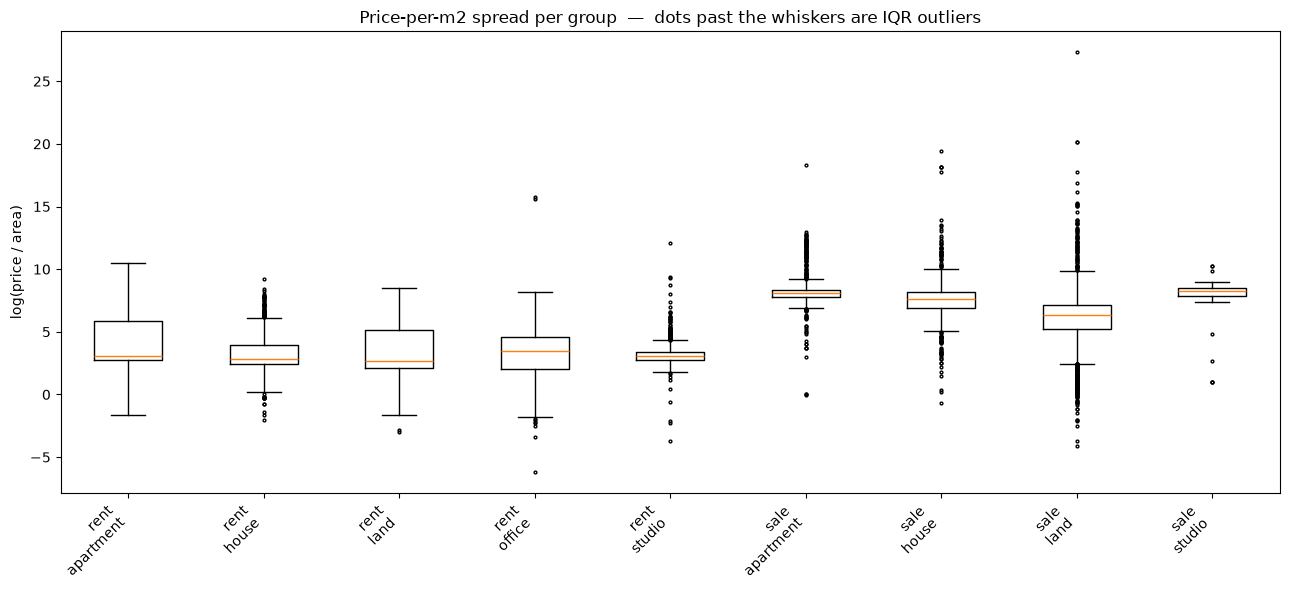

In [9]:
labels, data = [], []
for (lt, pt), g in filtered.groupby(["listing_type", "property_type"]):
    if len(g) >= MIN_OUTLIER_GROUP_SIZE:
        labels.append(f"{lt}\n{pt}")
        data.append(g["log_ppm2"].to_numpy())

fig, ax = plt.subplots(figsize=(13, 6))
ax.boxplot(data, tick_labels=labels, showfliers=True, flierprops=dict(marker=".", markersize=4))
ax.set_ylabel("log(price / area)")
ax.set_title("Price-per-m2 spread per group  —  dots past the whiskers are IQR outliers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 5b. Histogram with the fence drawn
The red dashed lines are the lower/upper fence for one group. Everything outside them is excluded. Change the arguments to inspect any group.

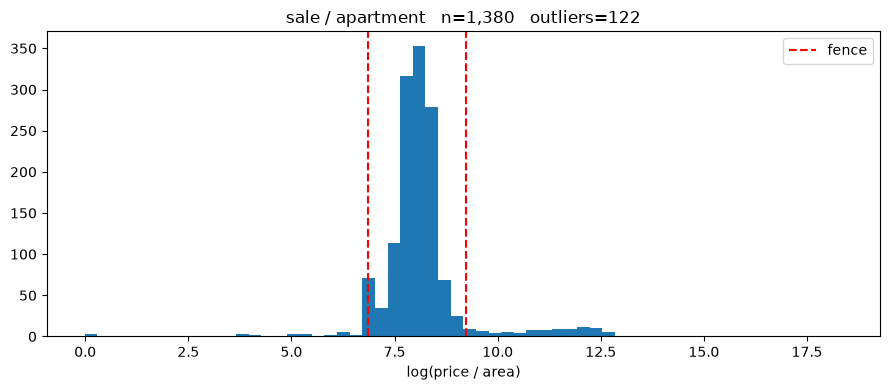

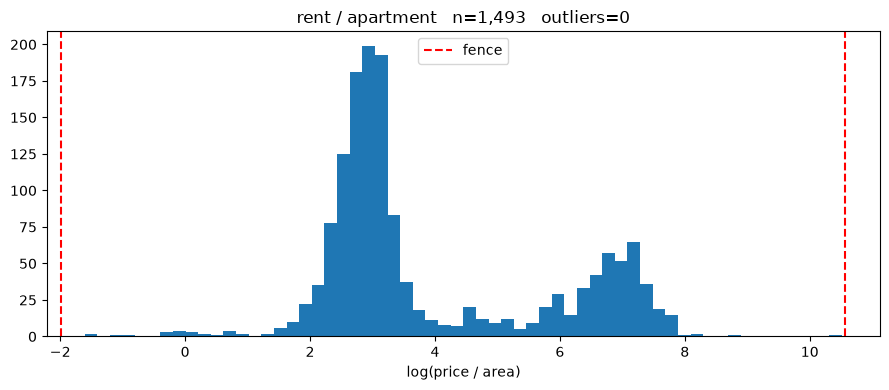

In [10]:
def plot_group(listing_type, property_type, bins=60):
    g = filtered[(filtered.listing_type == listing_type) & (filtered.property_type == property_type)]
    if (listing_type, property_type) not in bounds.index:
        print("no fence for this group (too small / not present)")
        return
    lo, hi = bounds.loc[(listing_type, property_type), ["lower", "upper"]]
    n_out = int((~g["log_ppm2"].between(lo, hi)).sum())

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(g["log_ppm2"], bins=bins)
    if np.isfinite(lo):
        ax.axvline(lo, color="red", ls="--", label="fence")
    if np.isfinite(hi):
        ax.axvline(hi, color="red", ls="--")
    ax.set_title(f"{listing_type} / {property_type}   n={len(g):,}   outliers={n_out:,}")
    ax.set_xlabel("log(price / area)")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_group("sale", "apartment")
plot_group("rent", "apartment")

### 5c. The most extreme excluded listings
Sorted by price-per-m2 so the obvious garbage (currency mixups, typos) surfaces at the top. This is the table to eyeball if you're deciding whether some aberrations are *correctable* rather than junk.

In [11]:
outliers = joined[joined["is_outlier"]].copy()
outliers["price_per_m2"] = (outliers["price"] / outliers["area"]).round(1)

# The fence is applied to log(price / area). Convert each group's log-bounds
# back to readable price-per-m2 values so you can compare them to the row's own
# price_per_m2, and record WHICH side of the fence the row broke.
outliers["fence_low_ppm2"] = np.exp(outliers["lower"]).round(1)
outliers["fence_high_ppm2"] = np.exp(outliers["upper"]).round(1)
outliers["why_outlier"] = np.where(
    outliers["log_ppm2"] > outliers["upper"], "price/m2 too HIGH (> fence_high)",
    np.where(outliers["log_ppm2"] < outliers["lower"], "price/m2 too LOW (< fence_low)", ""),
)

# NOTE: the fence tests the RATIO price/area, so "too HIGH" can mean an inflated
# price OR an abnormally tiny area (e.g. area = 3 m2), and "too LOW" often means
# a price entered in the wrong currency unit (dinars vs millimes). The column
# tells you which side broke; eyeball area + price to see which value is at fault.
cols = ["id", "source", "listing_type", "property_type", "governorate",
        "area", "price", "price_per_m2", "fence_low_ppm2", "fence_high_ppm2", "why_outlier"]
all_outliers = outliers.sort_values("price_per_m2", ascending=False)[cols].reset_index(drop=True)

print(f"{len(all_outliers):,} outlier listings")
print(all_outliers["why_outlier"].value_counts().to_string())

# Plain numbers instead of 1.11e+14 scientific notation, and show every row.
with pd.option_context("display.max_rows", None, "display.float_format", lambda v: f"{v:,.1f}"):
    display(all_outliers)

606 outlier listings
why_outlier
price/m2 too HIGH (> fence_high)    333
price/m2 too LOW (< fence_low)      273


,id,source,listing_type,property_type,governorate,area,price,price_per_m2,fence_low_ppm2,fence_high_ppm2,why_outlier
0,58786,tayara,sale,land,Ariana,154.0,"111,111,114,000,000.0","721,500,740,259.7",11.8,"19,917.2",price/m2 too HIGH (> fence_high)
1,60354,tayara,sale,land,Nabeul,200.0,"111,111,110,000.0","555,555,550.0",11.8,"19,917.2",price/m2 too HIGH (> fence_high)
2,58916,tayara,sale,land,Nabeul,2.0,"1,100,000,000.0","550,000,000.0",11.8,"19,917.2",price/m2 too HIGH (> fence_high)
3,57581,tayara,sale,house,Médenine,2.0,"570,000,000.0","285,000,000.0",150.5,"23,475.0",price/m2 too HIGH (> fence_high)
4,58319,tayara,sale,apartment,Tunis,3.0,"280,000,000.0","93,333,333.3",960.5,"10,265.5",price/m2 too HIGH (> fence_high)
5,58406,tayara,sale,house,Nabeul,3.0,"230,000,000.0","76,666,666.7",150.5,"23,475.0",price/m2 too HIGH (> fence_high)
6,58409,tayara,sale,house,Nabeul,3.0,"230,000,000.0","76,666,666.7",150.5,"23,475.0",price/m2 too HIGH (> fence_high)
7,58407,tayara,sale,house,Nabeul,3.0,"230,000,000.0","76,666,666.7",150.5,"23,475.0",price/m2 too HIGH (> fence_high)
8,60829,tayara,sale,land,Nabeul,220.0,"11,111,111,000.0","50,505,050.0",11.8,"19,917.2",price/m2 too HIGH (> fence_high)
9,57416,tayara,sale,house,Ariana,3.0,"150,000,000.0","50,000,000.0",150.5,"23,475.0",price/m2 too HIGH (> fence_high)


## 6. The features the model actually trains on (derived)

Sections 2–5 describe the *raw* rows. But the model doesn't train on those columns as-is: `to_feature_frame()` (the single function shared by training and serving) turns each cleaned row into the model's real input, adding three kinds of feature that are **not stored in the DB** and are recomputed every time from the text above:

- **`neighborhood`** — a canonical Grand-Tunis micro-area resolved from `address`/`city`/`title`/`description` (`scraper/neighborhood.py`). City alone isn't granular enough — most Tunis rows just say `city = "Tunis"`.
- **`delegation`** — a town-level location, one step finer than `governorate` (`scraper/governorate.py`). It covers the rural towns (mostly land) that the urban neighborhood gazetteer misses.
- **`land_*`** — 11 land-use / legal / servicing flags (agricultural, titled, serviced, beachfront, constructible…) parsed from the listing text (`scraper/land_features.py`). They're `NaN` for every non-land row, so the model simply ignores them there; for land they carry the price signal that isn't in any structured column.

Running `to_feature_frame` on the cleaned rows below shows the full feature matrix the model receives — categoricals first (as the pipeline's `ColumnTransformer` expects), then numerics.

In [12]:
from scraper.ml.features import to_feature_frame, ALL_FEATURES, CATEGORICAL_FEATURES, NUMERIC_FEATURES

# `kept` (the post-outlier-fence rows) is exactly what train_price_model.py feeds in.
X = to_feature_frame(kept)

print(f"{len(ALL_FEATURES)} model features = "
      f"{len(CATEGORICAL_FEATURES)} categorical + {len(NUMERIC_FEATURES)} numeric")
print("categorical:", CATEGORICAL_FEATURES)
print("numeric    :", NUMERIC_FEATURES)
schema_report(X)

24 model features = 7 categorical + 17 numeric
categorical: ['listing_type', 'property_type', 'governorate', 'city', 'subcategory', 'neighborhood', 'delegation']
numeric    : ['area', 'bedrooms', 'garage', 'furnished', 'terrace', 'pool', 'land_agricole', 'land_industriel', 'land_touristique', 'land_residentiel', 'land_titled', 'land_serviced', 'land_beachfront', 'land_fenced', 'land_lotissement', 'land_road_access', 'land_constructible']


,column,dtype,non_null,nulls,null_%,unique,min,median,max
0,listing_type,object,8090,0,0.0,2,NaN,NaN,NaN
1,property_type,object,8090,0,0.0,5,NaN,NaN,NaN
2,governorate,object,8090,0,0.0,26,NaN,NaN,NaN
3,city,object,8090,0,0.0,139,NaN,NaN,NaN
4,subcategory,object,8090,0,0.0,5,NaN,NaN,NaN
5,neighborhood,object,5343,2747,34.0,73,NaN,NaN,NaN
6,delegation,object,8086,4,0.0,183,NaN,NaN,NaN
7,area,float64,8090,0,0.0,1249,1.0,200.0,320000.0
8,bedrooms,float64,2492,5598,69.2,15,0.0,2.0,15.0
9,garage,float64,1134,6956,86.0,2,0.0,0.0,1.0


In [13]:
# Coverage of the derived location features, and how often each land_* flag fires
# among land rows (they are NaN - hence excluded here - for every non-land row).
print(f"neighborhood resolved: {X['neighborhood'].notna().mean()*100:4.0f}%   ({X['neighborhood'].nunique()} distinct)")
print(f"delegation resolved  : {X['delegation'].notna().mean()*100:4.0f}%   ({X['delegation'].nunique()} distinct)")

land_flags = [c for c in NUMERIC_FEATURES if c.startswith("land_")]
is_land = X["property_type"] == "land"
cov = (X.loc[is_land, land_flags] == 1).mean().mul(100).round(0).astype(int)
cov = cov.sort_values(ascending=False).rename("pct_of_land_rows_where_flag_is_1")
cov.to_frame()

neighborhood resolved:   66%   (73 distinct)
delegation resolved  :  100%   (183 distinct)


,pct_of_land_rows_where_flag_is_1
land_residentiel,44
land_titled,33
land_road_access,30
land_beachfront,18
land_agricole,12
land_serviced,11
land_fenced,7
land_constructible,7
land_lotissement,6
land_touristique,5


## Summary

- **Section 2** is the *raw variable schema* — the source columns, their types, missingness and ranges.
- **Sections 3–5** are the *outliers* — the two exclusion stages and how the IQR fence flags aberrant prices, as tables and plots.
- **Section 6** is the *derived feature matrix* — what `to_feature_frame` actually hands the model, including the on-the-fly `neighborhood`, `delegation` and `land_*` features.

Nothing here modifies the database; it all runs on an in-memory copy, exactly like the training pipeline. To change what gets **excluded**, edit the thresholds in `scraper/ml/prepare_training_data.py` (`MIN_SALE_PRICE`, `MIN_OUTLIER_GROUP_SIZE`, or the `iqr_multiplier`). To change what **features** the model sees, edit `scraper/ml/features.py` (and retrain — the pipeline addresses columns positionally, so a feature change needs a fresh artifact).